# Part 2 — YOLOX + OC-SORT + Scene Cut + OSNet Recovery

## Goal

Use exactly the frozen YOLOX cache from Part 1. At a detected hard cut, discard
OC-SORT's short-term motion/Kalman state, retain a long-term gallery of OSNet
appearance embeddings, and restore an old global identity only when its
one-to-one cosine similarity is at least the conservative configured threshold.

No model is trained or fine-tuned. The source remains only
`v_gQNyhv8y0QY_c013` read directly from its original image folder.

## Invariant at a hard cut

```text
discard: local OC-SORT tracks + Kalman state
preserve: OSNet embedding gallery + global identity memory
recover: only a one-to-one match with cosine similarity ≥ 0.75
otherwise: allocate a new global ID
```

In [1]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path(r"D:\Bunker\BaseCamp\SceneCut Aware tracking")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from scenecut_tracking.config import load_config
from scenecut_tracking.detection_cache import DetectionCache, build_detection_cache
from scenecut_tracking.evaluation import evaluate_mot
from scenecut_tracking.frame_source import read_source_metadata
from scenecut_tracking.runner import run_video

CONFIG = load_config(PROJECT_ROOT / "configs" / "default.yaml")
SEQUENCE_ROOT = PROJECT_ROOT / "data" / "SportsMOT-Example" / "dataset" / "train" / "v_gQNyhv8y0QY_c013"
GROUND_TRUTH_PATH = SEQUENCE_ROOT / "gt" / "gt.txt"
DETECTION_CACHE_PATH = PROJECT_ROOT / "outputs" / "detections" / "sportsmot_c013_yolox_s_cpu.npz"

assert SEQUENCE_ROOT.is_dir(), SEQUENCE_ROOT
assert GROUND_TRUTH_PATH.is_file(), GROUND_TRUTH_PATH
assert CONFIG["detector"]["backend"] == "yolox"
assert CONFIG["detector"]["device"] == "cpu"
assert CONFIG["reid"]["device"] == "cpu"

metadata = read_source_metadata(SEQUENCE_ROOT)
print(metadata.to_dict())

{'path': 'D:\\Bunker\\BaseCamp\\SceneCut Aware tracking\\data\\SportsMOT-Example\\dataset\\train\\v_gQNyhv8y0QY_c013', 'fingerprint': '28a99dd6a303e7d3ae397304070694b4e0d7b9608cee58935afc7ec3c42759e7', 'frame_count': 875, 'width': 1280, 'height': 720, 'fps': 25.0}


## 1. Verify the shared detector cache

In [2]:
IMPROVED_OUTPUT = PROJECT_ROOT / "outputs" / "improved" / "sportsmot_c013_yolox_ocsort_scenecut_osnet_cpu"
BASELINE_OUTPUT = PROJECT_ROOT / "outputs" / "baseline" / "sportsmot_c013_yolox_ocsort_cpu"
COMPARISON_OUTPUT = PROJECT_ROOT / "outputs" / "comparison" / "sportsmot_c013_yolox_cpu"
RUN_EXPERIMENT = False

cache = DetectionCache.load(DETECTION_CACHE_PATH)
cache.validate_source(SEQUENCE_ROOT)
assert cache.metadata["detector"]["backend"] == "yolox"
print("Shared cache:", DETECTION_CACHE_PATH)
print("Cached detection rows:", len(cache.rows))

Shared cache: D:\Bunker\BaseCamp\SceneCut Aware tracking\outputs\detections\sportsmot_c013_yolox_s_cpu.npz
Cached detection rows: 14239


## 2. Run scene-cut-aware tracking and selective ReID

OSNet embeddings are retained as bounded gallery memories. Matching is not used
as an unrestricted tracker association mechanism; it is activated only after a
scene-cut event and is threshold-gated to reduce false identity merges.

In [3]:
if RUN_EXPERIMENT or not (IMPROVED_OUTPUT / "paper_metrics.json").exists():
    improved_summary = run_video(
        mode="improved",
        video_path=SEQUENCE_ROOT,
        detection_cache_path=DETECTION_CACHE_PATH,
        output_dir=IMPROVED_OUTPUT,
        config=CONFIG,
        project_root=PROJECT_ROOT,
    )
    improved_metrics = evaluate_mot(GROUND_TRUTH_PATH, IMPROVED_OUTPUT / "tracks_mot.txt")
    (IMPROVED_OUTPUT / "paper_metrics.json").write_text(json.dumps(improved_metrics, indent=2))
else:
    improved_summary = json.loads((IMPROVED_OUTPUT / "metrics.json").read_text())
    improved_metrics = json.loads((IMPROVED_OUTPUT / "paper_metrics.json").read_text())

baseline_metrics = json.loads((BASELINE_OUTPUT / "paper_metrics.json").read_text())
print("Improved runtime summary")
print(json.dumps(improved_summary, indent=2))

Improved runtime summary
{
  "mode": "improved",
  "frames": 875,
  "source_fps": 25.0,
  "processing_fps": 6.45570106963999,
  "elapsed_seconds": 135.53911349999908,
  "track_rows": 2853,
  "unique_global_ids": 507,
  "detected_scene_cuts": 0,
  "cut_frames": [],
  "accepted_recoveries": 0,
  "average_recovery_similarity": null,
  "annotated_video": "D:\\Bunker\\BaseCamp\\SceneCut Aware tracking\\outputs\\improved\\sportsmot_c013_yolox_ocsort_scenecut_osnet_cpu\\annotated_improved.mp4",
  "tracks_mot": "D:\\Bunker\\BaseCamp\\SceneCut Aware tracking\\outputs\\improved\\sportsmot_c013_yolox_ocsort_scenecut_osnet_cpu\\tracks_mot.txt"
}


## 3. Compare paper-aligned metrics

In [4]:
import pandas as pd

comparison = pd.DataFrame(
    {"YOLOX + OC-SORT": baseline_metrics, "YOLOX + OC-SORT + Scene Cut + OSNet": improved_metrics}
).loc[["HOTA", "DetA", "AssA", "IDF1", "MOTA", "FP", "FN", "IDs", "Frag"]]
display(comparison)

,YOLOX + OC-SORT,YOLOX + OC-SORT + Scene Cut + OSNet
HOTA,0.209025,0.209025
DetA,0.122943,0.122943
AssA,0.384645,0.384645
IDF1,0.059657,0.059657
MOTA,-26.948944,-26.948944
FP,2849.000000,2849.000000
FN,10553.000000,10553.000000
IDs,0.000000,0.000000
Frag,0.000000,0.000000


## 4. Interpret the real result correctly

The selected SportsMOT clip produced **zero hard scene cuts** under the
configured content detector. Consequently, the improved system performed zero
motion resets and zero ReID recoveries, and its tracking metrics match the
baseline. This is expected behaviour: there is no discontinuity to repair.

This clip therefore validates that the enhancement does not invent identity
changes when no cut is present, but it cannot prove cross-cut recovery quality.
That claim would require a source containing labelled real cuts or an explicitly
labelled controlled stress test.

Event counts: Counter({'identity_assignment': 507})
Detected scene cuts: 0
Accepted recovery events: 0
D:\Bunker\BaseCamp\SceneCut Aware tracking\outputs\comparison\sportsmot_c013_yolox_cpu\paper_metrics_comparison.png


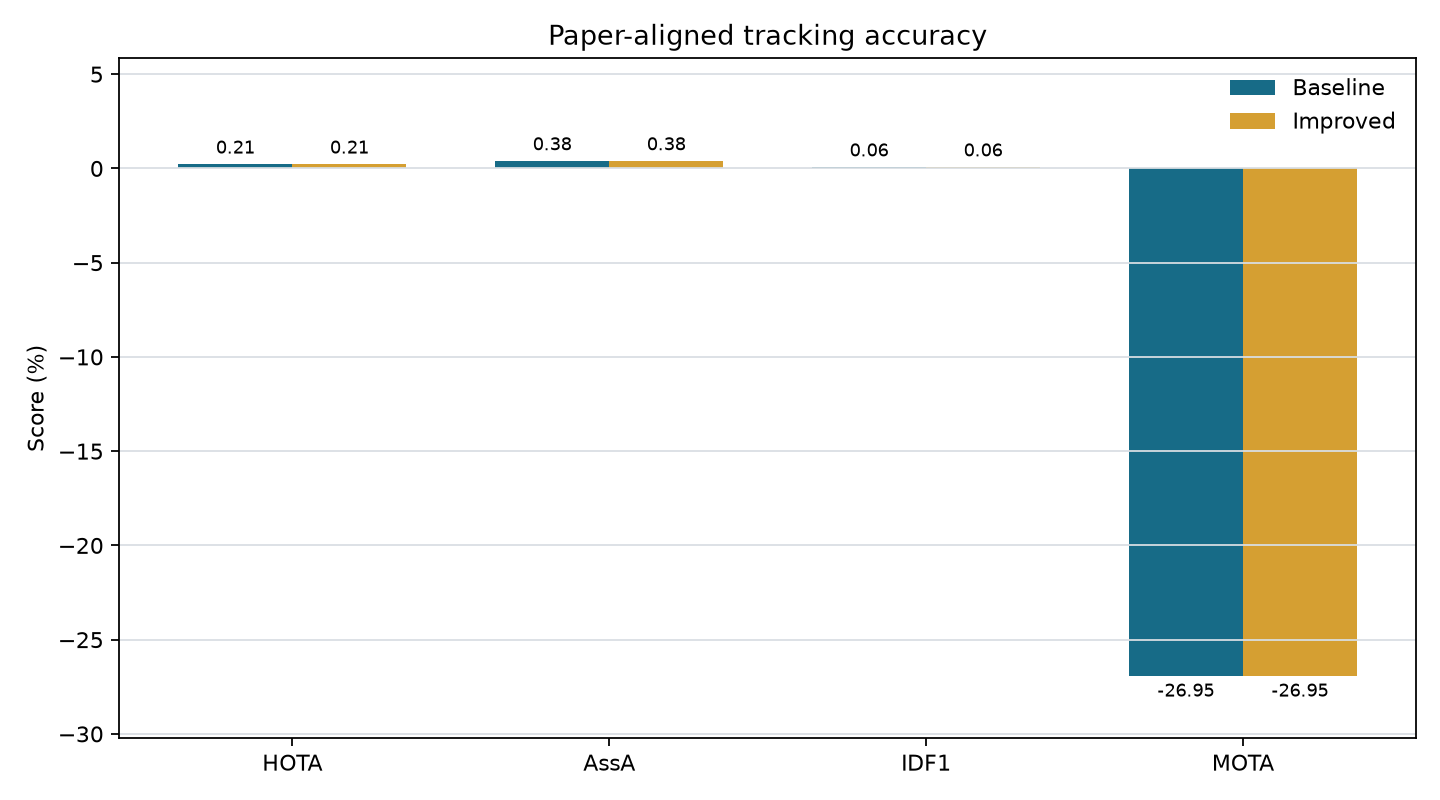

D:\Bunker\BaseCamp\SceneCut Aware tracking\outputs\comparison\sportsmot_c013_yolox_cpu\tracking_errors_comparison.png


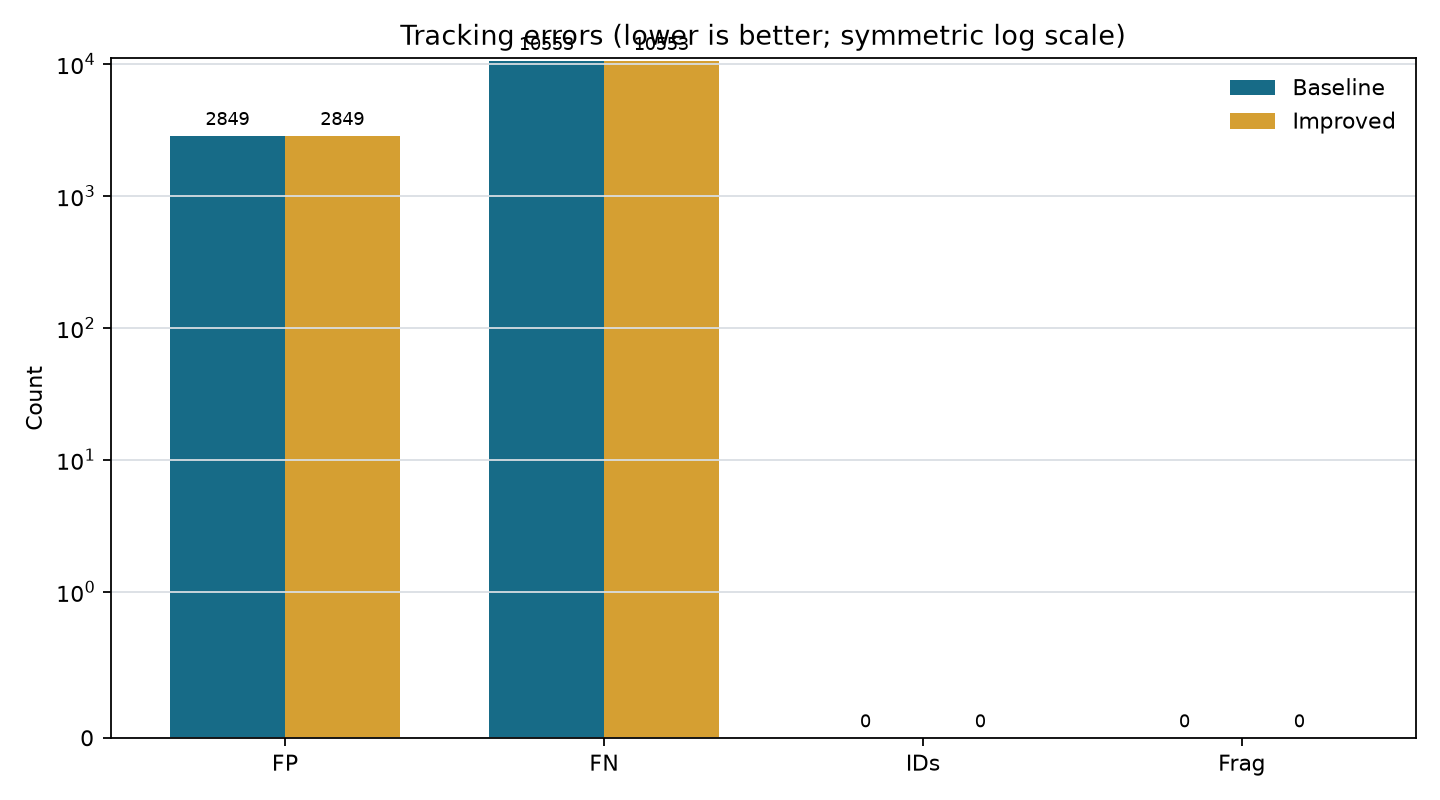

In [5]:
from collections import Counter
from IPython.display import Image, display

events_path = IMPROVED_OUTPUT / "events.jsonl"
events = [json.loads(line) for line in events_path.read_text().splitlines() if line.strip()]
print("Event counts:", Counter(event["event"] for event in events))
print("Detected scene cuts:", improved_summary["detected_scene_cuts"])
print("Accepted recovery events:", improved_summary["accepted_recoveries"])

for name in ["paper_metrics_comparison.png", "tracking_errors_comparison.png"]:
    path = COMPARISON_OUTPUT / name
    print(path)
    display(Image(filename=str(path)))

## Takeaway

The implementation is working as designed on this source: CPU-only, same
YOLOX detections, zero automatic reset without a detected cut, and no unsafe
appearance-based ID reassignment. It costs additional appearance-extraction
runtime (6.46 FPS versus 16.11 FPS for baseline) but cannot improve a sequence
that has no cut event to recover from.